In [1]:
# ============================================================
# CELL 1
# INSTALL LIBRARY
# ============================================================

# Kode ini hanya dijalankan ketika menggunakan Google Colab.
# Skorch digunakan sebagai penghubung antara PyTorch dan Scikit-learn.
import subprocess

try:
    import google.colab

    subprocess.run([
        'python',
        '-m',
        'pip',
        'install',
        '-q',
        'skorch'
    ])

except ImportError:
    pass

In [2]:
# ============================================================
# CELL 2
# IMPORT LIBRARY
# ============================================================

# Digunakan untuk mengakses dataset MNIST
from sklearn.datasets import fetch_openml

# Digunakan untuk membagi dataset menjadi training dan testing
from sklearn.model_selection import train_test_split

# Digunakan untuk menghitung accuracy
from sklearn.metrics import accuracy_score

# Digunakan untuk membuat confusion matrix
from sklearn.metrics import confusion_matrix

# Digunakan untuk membuat classification report
from sklearn.metrics import classification_report

# Library untuk manipulasi data
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt

# Library untuk membuat confusion matrix lebih mudah dibaca
import seaborn as sns

# Library Deep Learning PyTorch
import torch
from torch import nn
import torch.nn.functional as F

# Skorch menghubungkan PyTorch dengan API seperti scikit-learn
from skorch import NeuralNetClassifier

In [3]:
# ============================================================
# CELL 3
# LOAD DATASET MNIST
# ============================================================

# Mengambil dataset MNIST dari OpenML.
#
# MNIST berisi gambar angka tulisan tangan 0 sampai 9.
#
# Setiap gambar berukuran:
# 28 x 28 pixel
#
# Karena 28 x 28 = 784,
# setiap gambar memiliki 784 nilai pixel.
mnist = fetch_openml(
    'mnist_784',
    as_frame=False,
    cache=False
)

# Melihat ukuran dataset
print("Ukuran dataset:")
print(mnist.data.shape)

Ukuran dataset:
(70000, 784)


In [4]:
# ============================================================
# CELL 4
# MEMISAHKAN DATA DAN LABEL
# ============================================================

# X berisi data gambar/pixel
X = mnist.data.astype('float32')

# y berisi label angka 0 sampai 9
y = mnist.target.astype('int64')

# Nilai pixel MNIST awalnya berada pada rentang:
# 0 sampai 255
#
# Kita ubah menjadi:
# 0 sampai 1
#
# Proses ini disebut normalisasi.
X /= 255.0

print("Shape X :", X.shape)
print("Shape y :", y.shape)

print("\nContoh label:")
print(y[:10])

Shape X : (70000, 784)
Shape y : (70000,)

Contoh label:
[5 0 4 1 9 2 1 3 1 4]


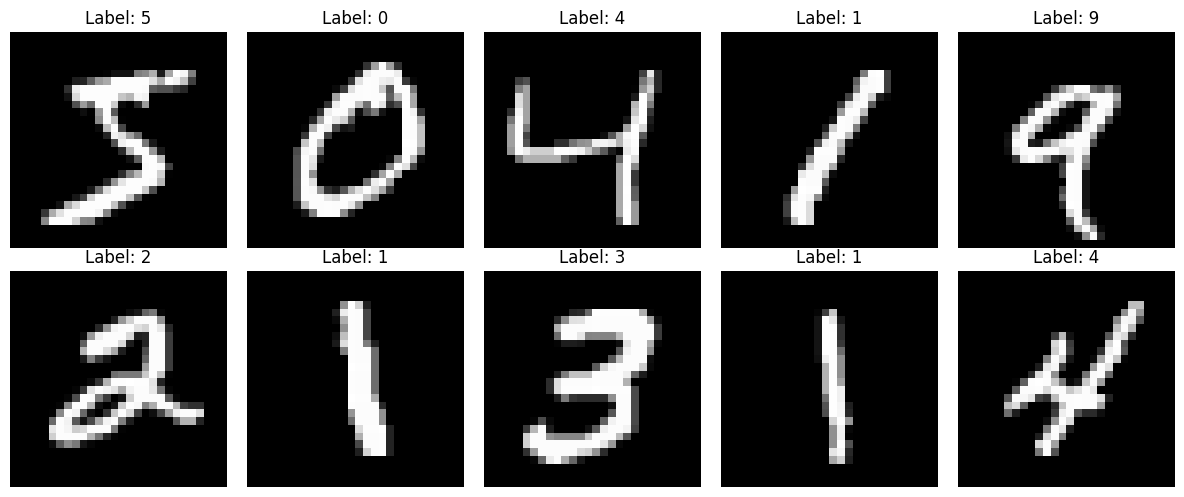

In [ ]:
# ============================================================
# CELL 5
# MENAMPILKAN DATA AWAL MNIST
# ============================================================

# Mengambil 10 gambar pertama
plt.figure(figsize=(12, 5))

for i in range(10):

    # Membuat subplot 2 baris x 5 kolom
    plt.subplot(2, 5, i + 1)

    # Data awal berbentuk 784 pixel.
    # Kita ubah kembali menjadi 28 x 28
    image = X[i].reshape(28, 28)

    # Menampilkan gambar grayscale
    plt.imshow(
        image,
        cmap='gray'
    )

    # Menampilkan label sebenarnya
    plt.title(
        f"Label: {y[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 6
# TRAIN TEST SPLIT
# ============================================================

# Dataset dibagi menjadi:
#
# 75% -> training
# 25% -> testing
#
# random_state=42 digunakan agar hasil pembagian
# tetap sama setiap kali kode dijalankan.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Data training:")
print(X_train.shape)

print("\nData testing:")
print(X_test.shape)

print("\nLabel training:")
print(y_train.shape)

print("\nLabel testing:")
print(y_test.shape)

Data training:
(52500, 784)

Data testing:
(17500, 784)

Label training:
(52500,)

Label testing:
(17500,)


In [ ]:
# ============================================================
# CELL 7
# MENENTUKAN DEVICE
# ============================================================

# Jika GPU tersedia maka PyTorch akan menggunakan CUDA.
# Jika tidak tersedia maka menggunakan CPU.

device = (
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

print("Device yang digunakan:", device)

Device yang digunakan: cpu


In [ ]:
# ============================================================
# CELL 8
# PARAMETER ANN
# ============================================================

# Jumlah input:
# 28 x 28 = 784 pixel
mnist_dim = X.shape[1]

# Jumlah neuron hidden layer
hidden_dim = int(
    mnist_dim / 8
)

# MNIST memiliki 10 kelas:
# angka 0 sampai 9
output_dim = len(
    np.unique(y)
)

print("Input dimension :", mnist_dim)
print("Hidden dimension:", hidden_dim)
print("Output dimension:", output_dim)

Input dimension : 784
Hidden dimension: 98
Output dimension: 10


In [ ]:
# ============================================================
# CELL 9
# MEMBUAT MODEL ANN
# ============================================================

# ============================================================
# MODEL ANN
# ============================================================

class ClassifierModule(nn.Module):

    def __init__(
        self,
        input_dim=784,
        hidden_dim=98,
        output_dim=10,
        dropout=0.5
    ):

        # Memanggil constructor dari PyTorch
        super().__init__()

        # Hidden layer
        #
        # 784 input berasal dari:
        # 28 x 28 = 784 pixel
        self.hidden = nn.Linear(
            input_dim,
            hidden_dim
        )

        # Dropout digunakan untuk mengurangi overfitting
        self.dropout = nn.Dropout(
            dropout
        )

        # Output layer
        #
        # 10 neuron karena MNIST memiliki
        # 10 kelas: 0 sampai 9
        self.output = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(self, X):

        # Masuk ke hidden layer
        X = self.hidden(X)

        # Activation function ReLU
        X = F.relu(X)

        # Dropout
        X = self.dropout(X)

        # Output berupa logits
        #
        # TIDAK menggunakan softmax.
        X = self.output(X)

        return X

In [ ]:
# ============================================================
# CELL 10
# NN CLASSIFIER
# ============================================================


# Menentukan random seed
torch.manual_seed(0)

net = NeuralNetClassifier(

    # Model ANN
    ClassifierModule,

    # Jumlah epoch
    max_epochs=20,

    # Learning rate
    lr=0.001,

    # Optimizer Adam
    optimizer=torch.optim.Adam,

    # Loss function
    #
    # CrossEntropyLoss secara internal menangani
    # perhitungan yang berkaitan dengan softmax.
    criterion=torch.nn.CrossEntropyLoss,

    # Ukuran batch
    batch_size=128,

    # Menggunakan GPU jika tersedia
    device=device
)

In [ ]:
# ============================================================
# CEK DATA SEBELUM TRAINING
# ============================================================

print("Apakah X mengandung NaN?")
print(np.isnan(X_train).any())

print("\nApakah X mengandung Inf?")
print(np.isinf(X_train).any())

print("\nNilai minimum X:")
print(X_train.min())

print("\nNilai maksimum X:")
print(X_train.max())

print("\nLabel:")
print(np.unique(y_train))

Apakah X mengandung NaN?
False

Apakah X mengandung Inf?
False

Nilai minimum X:
0.0

Nilai maksimum X:
1.0

Label:
[0 1 2 3 4 5 6 7 8 9]


In [ ]:
# ============================================================
# CELL 11
# TRAINING ANN
# ============================================================

print("Memulai training ANN...")

net.fit(
    X_train,
    y_train
)

print("Training ANN selesai.")

Memulai training ANN...
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.7002       0.9118        0.3142  1.2970
      2        0.3528       0.9303        0.2381  1.9847
      3        0.2878       0.9421        0.2007  1.7089
      4        0.2512       0.9470        0.1758  1.4283
      5        0.2289       0.9514        0.1617  1.4145
      6        0.2075       0.9554        0.1507  1.4534
      7        0.2009       0.9587        0.1410  1.4386
      8        0.1897       0.9608        0.1340  1.3894
      9        0.1777       0.9610        0.1287  1.4201
     10        0.1681       0.9627        0.1254  1.8341
     11        0.1640       0.9633        0.1220  1.9486
     12        0.1557       0.9641        0.1184  1.4272
     13        0.1526       0.9656        0.1127  1.4203
     14        0.1486       0.9668        0.1122  1.3999
     15        0.1433       0.9669        0.1088  1.4336
     16

In [ ]:
# ============================================================
# CELL 12
# PREDIKSI ANN
# ============================================================

# Model digunakan untuk melakukan prediksi
# terhadap data testing.

y_pred = net.predict(
    X_test
)

print("Contoh label sebenarnya:")
print(y_test[:20])

print("\nContoh hasil prediksi:")
print(y_pred[:20])

Contoh label sebenarnya:
[8 4 8 7 7 0 6 2 7 4 3 9 9 8 2 5 9 1 7 8]

Contoh hasil prediksi:
[8 4 8 7 7 0 6 2 7 4 3 9 9 8 2 5 9 1 7 8]


In [ ]:
# ============================================================
# CELL 13
# ACCURACY ANN
# ============================================================

# Menghitung jumlah prediksi yang benar
# dibandingkan seluruh data testing.

accuracy_ann = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy ANN: "
    f"{accuracy_ann * 100:.2f}%"
)

Accuracy ANN: 96.77%


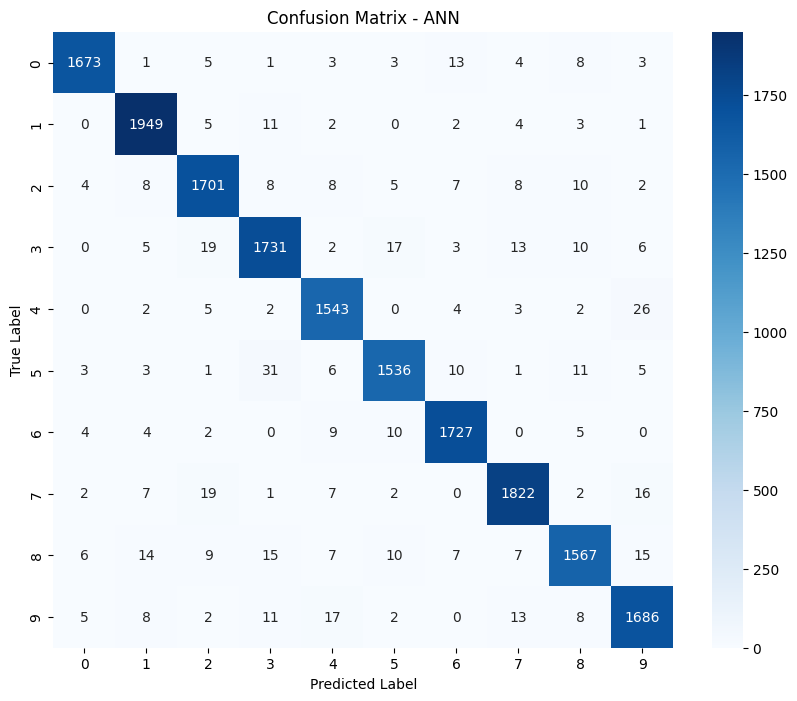

In [ ]:
# ============================================================
# CELL 14
# CONFUSION MATRIX ANN
# ============================================================

# Membuat confusion matrix
cm_ann = confusion_matrix(
    y_test,
    y_pred
)

# Membuat ukuran gambar
plt.figure(
    figsize=(10, 8)
)

# Menampilkan confusion matrix
sns.heatmap(
    cm_ann,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Confusion Matrix - ANN"
)

plt.show()

In [ ]:
# ============================================================
# CELL 15
# CLASSIFICATION REPORT ANN
# ============================================================

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1714
           1       0.97      0.99      0.98      1977
           2       0.96      0.97      0.96      1761
           3       0.96      0.96      0.96      1806
           4       0.96      0.97      0.97      1587
           5       0.97      0.96      0.96      1607
           6       0.97      0.98      0.98      1761
           7       0.97      0.97      0.97      1878
           8       0.96      0.95      0.95      1657
           9       0.96      0.96      0.96      1752

    accuracy                           0.97     17500
   macro avg       0.97      0.97      0.97     17500
weighted avg       0.97      0.97      0.97     17500



Jumlah prediksi benar: 16935


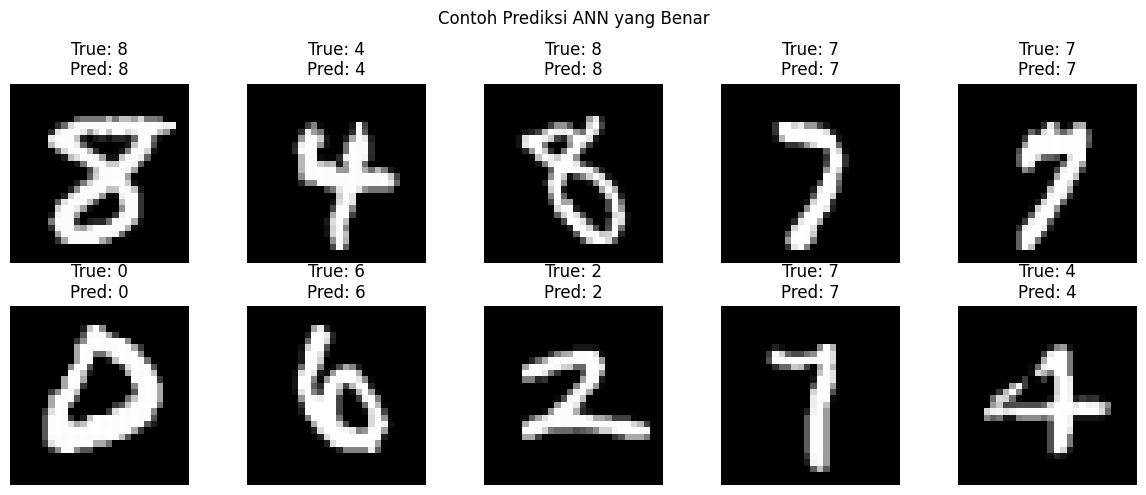

In [ ]:
# ============================================================
# CELL 16
# CONTOH PREDIKSI ANN YANG BENAR
# ============================================================

# Mencari posisi data yang prediksinya benar
correct_indices = np.where(
    y_pred == y_test
)[0]

print(
    "Jumlah prediksi benar:",
    len(correct_indices)
)

# Menampilkan maksimal 10 gambar
plt.figure(
    figsize=(12, 5)
)

for i in range(
    min(10, len(correct_indices))
):

    # Mengambil index data
    index = correct_indices[i]

    # Mengubah 784 pixel menjadi 28 x 28
    image = X_test[index].reshape(
        28,
        28
    )

    plt.subplot(
        2,
        5,
        i + 1
    )

    plt.imshow(
        image,
        cmap='gray'
    )

    plt.title(
        f"True: {y_test[index]}\n"
        f"Pred: {y_pred[index]}"
    )

    plt.axis('off')

plt.suptitle(
    "Contoh Prediksi ANN yang Benar"
)

plt.tight_layout()
plt.show()

Jumlah prediksi salah: 565


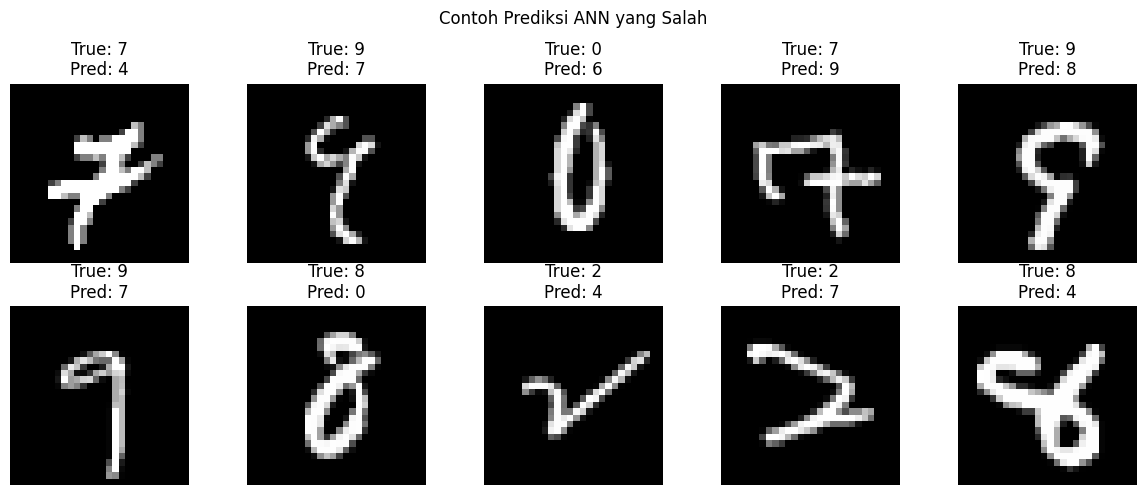

In [ ]:
# ============================================================
# CELL 17
# CONTOH PREDIKSI ANN YANG SALAH
# ============================================================

# Mencari posisi data yang prediksinya salah
wrong_indices = np.where(
    y_pred != y_test
)[0]

print(
    "Jumlah prediksi salah:",
    len(wrong_indices)
)

# Menampilkan maksimal 10 gambar
plt.figure(
    figsize=(12, 5)
)

for i in range(
    min(10, len(wrong_indices))
):

    index = wrong_indices[i]

    image = X_test[index].reshape(
        28,
        28
    )

    plt.subplot(
        2,
        5,
        i + 1
    )

    plt.imshow(
        image,
        cmap='gray'
    )

    plt.title(
        f"True: {y_test[index]}\n"
        f"Pred: {y_pred[index]}"
    )

    plt.axis('off')

plt.suptitle(
    "Contoh Prediksi ANN yang Salah"
)

plt.tight_layout()
plt.show()